In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
rows, cols = df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 284807
Columns: 31


In [5]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.188326e-16,-1.164018e-15,-9.082889e-16,2.085924e-17,-6.343731e-16,-1.018099e-15,-2.557889e-16,-1.347621e-16,...,-2.444306e-16,-4.201199e-16,6.217312e-16,-4.385333e-17,-9.832396e-16,-1.745526e-17,1.196577e-16,2.108702e-15,-0.227709,-0.101347
V2,-0.010593,4.188326e-16,1.000000e+00,3.140164e-16,-1.125909e-15,5.230686e-16,2.781752e-16,1.857398e-16,-5.698764e-17,2.006267e-17,...,-8.277282e-17,1.547272e-16,1.668081e-16,1.577058e-17,-4.530958e-16,1.984817e-16,-4.938067e-16,-5.182198e-16,-0.531409,0.091289
V3,-0.419618,-1.164018e-15,3.140164e-16,1.000000e+00,4.644369e-16,-5.483554e-17,1.627805e-15,5.239200e-16,-1.297365e-15,5.725902e-16,...,5.931009e-17,-1.115726e-15,-5.063673e-16,5.605700e-19,-1.118857e-15,-1.389572e-16,1.058098e-15,9.792787e-16,-0.210880,-0.192961
V4,-0.105260,-9.082889e-16,-1.125909e-15,4.644369e-16,1.000000e+00,-1.722056e-15,-7.565957e-16,-4.188169e-16,5.645256e-16,6.873528e-16,...,-1.862123e-16,-3.949686e-17,9.564529e-17,1.569977e-16,6.026069e-16,-4.237973e-16,4.577343e-17,-3.888959e-18,0.098732,0.133447
V5,0.173072,2.085924e-17,5.230686e-16,-5.483554e-17,-1.722056e-15,1.000000e+00,2.208263e-16,2.691713e-16,7.396815e-16,7.178142e-16,...,-3.990893e-16,1.277735e-16,-8.760100e-18,-1.142295e-15,5.021165e-16,4.450164e-16,6.538203e-16,-3.301835e-18,-0.386356,-0.094974
V6,-0.063016,-6.343731e-16,2.781752e-16,1.627805e-15,-7.565957e-16,2.208263e-16,1.000000e+00,1.213776e-16,-1.030439e-16,4.234240e-16,...,5.551919e-17,5.756004e-18,9.443837e-17,-1.070899e-15,4.568884e-16,-1.402561e-16,-4.500879e-16,2.493919e-16,0.215981,-0.043643
V7,0.084714,-1.018099e-15,1.857398e-16,5.239200e-16,-4.188169e-16,2.691713e-16,1.213776e-16,1.000000e+00,3.549393e-16,1.125386e-15,...,-2.122235e-16,-8.840620e-16,-4.458969e-16,9.812896e-18,-2.881866e-16,-9.494990e-16,-1.723845e-15,-2.921030e-16,0.397311,-0.187257
V8,-0.036949,-2.557889e-16,-5.698764e-17,-1.297365e-15,5.645256e-16,7.396815e-16,-1.030439e-16,3.549393e-16,1.000000e+00,4.340695e-16,...,3.830431e-16,2.065947e-16,6.910016e-17,-9.701203e-17,-4.609097e-16,-1.777597e-16,1.280491e-16,-6.187506e-16,-0.103079,0.019875
V9,-0.008660,-1.347621e-16,2.006267e-17,5.725902e-16,6.873528e-16,7.178142e-16,4.234240e-16,1.125386e-15,4.340695e-16,1.000000e+00,...,1.874693e-16,-6.976879e-16,-5.221067e-16,-1.449529e-16,6.679328e-16,-8.154251e-16,-6.111140e-17,1.106537e-15,-0.044246,-0.097733


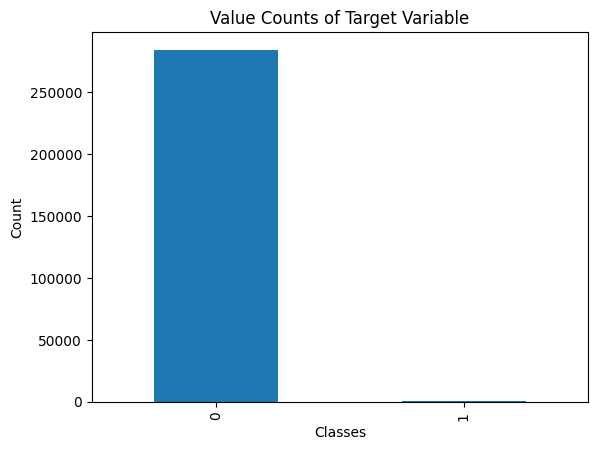

In [6]:
df['Class'].value_counts().plot(kind='bar')

plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Value Counts of Target Variable')
plt.show()

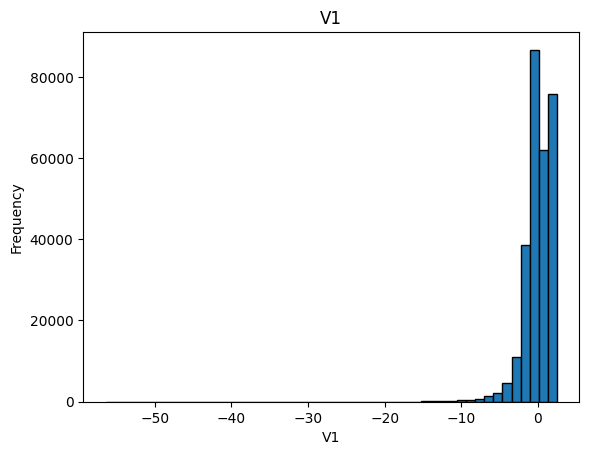

In [7]:
df['V1'].plot(kind='hist', bins=50, edgecolor='black')

plt.xlabel('V1')
plt.ylabel('Frequency')
plt.title('V1')
plt.show()

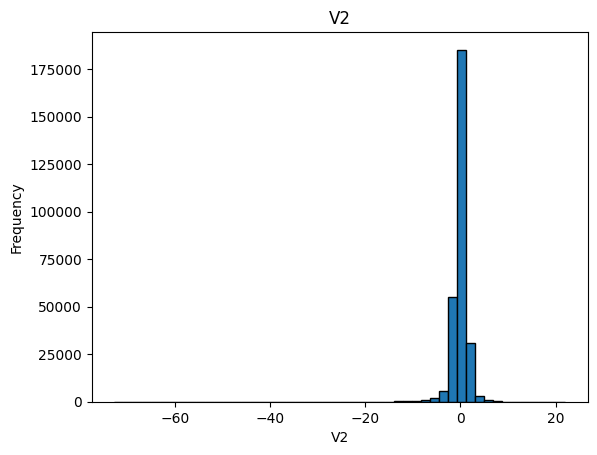

In [8]:
df['V2'].plot(kind='hist', bins=50, edgecolor='black')

plt.xlabel('V2')
plt.ylabel('Frequency')
plt.title('V2')
plt.show()

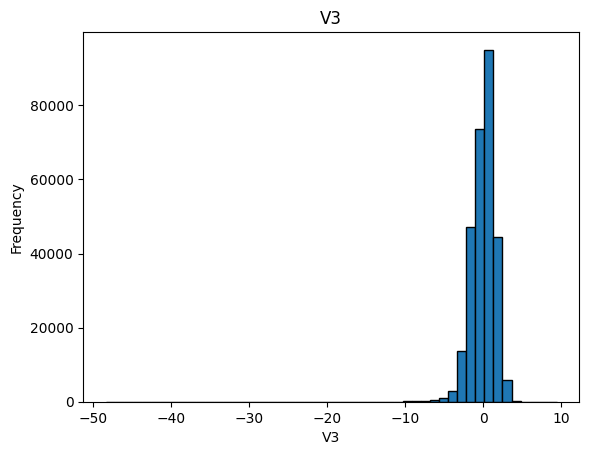

In [9]:
df['V3'].plot(kind='hist', bins=50, edgecolor='black')

plt.xlabel('V3')
plt.ylabel('Frequency')
plt.title('V3')
plt.show()

In [10]:
display(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
print(df.duplicated().sum())

1081


In [12]:
df.drop_duplicates(inplace=True, ignore_index=True)


In [13]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

There is a big class disparity. Accuracy wont be of much use as most classifiers will predict the 0 class very well and this will skew the accuracy. F1 score is much more important and telling of the classifiers performance as this will take into account precision and recall.

In [14]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [15]:
scaler = StandardScaler()
new_df = df.copy()


In [16]:
new_df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

In [17]:
new_df.drop(columns=['Time'], inplace=True)

In [18]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      283726 non-null  float64
 1   V2      283726 non-null  float64
 2   V3      283726 non-null  float64
 3   V4      283726 non-null  float64
 4   V5      283726 non-null  float64
 5   V6      283726 non-null  float64
 6   V7      283726 non-null  float64
 7   V8      283726 non-null  float64
 8   V9      283726 non-null  float64
 9   V10     283726 non-null  float64
 10  V11     283726 non-null  float64
 11  V12     283726 non-null  float64
 12  V13     283726 non-null  float64
 13  V14     283726 non-null  float64
 14  V15     283726 non-null  float64
 15  V16     283726 non-null  float64
 16  V17     283726 non-null  float64
 17  V18     283726 non-null  float64
 18  V19     283726 non-null  float64
 19  V20     283726 non-null  float64
 20  V21     283726 non-null  float64
 21  V22     28

In [19]:
X = new_df.loc[:, new_df.columns != 'Class'].values
y = new_df.loc[:, new_df.columns == 'Class'].values.ravel()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, f1_score, precision_recall_curve, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=0)

In [21]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

svc = SVC(random_state = 42)

dt = DecisionTreeClassifier(random_state=42)

mlp = MLPClassifier(alpha=0, random_state=42, max_iter=500)

rf = RandomForestClassifier(random_state=42)

In [22]:
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [23]:
y_pred = dt.predict(X_test)

In [24]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.76      0.76      0.76       236

    accuracy                           1.00    141863
   macro avg       0.88      0.88      0.88    141863
weighted avg       1.00      1.00      1.00    141863



In [25]:
print("f1 score:\n", f1_score(y_test, y_pred))

f1 score:
 0.7568710359408034


In [26]:
mlp.fit(X_train,y_train)

MLPClassifier(alpha=0, max_iter=500, random_state=42)

In [27]:
y_pred = mlp.predict(X_test)

In [28]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.92      0.75      0.82       236

    accuracy                           1.00    141863
   macro avg       0.96      0.87      0.91    141863
weighted avg       1.00      1.00      1.00    141863



In [29]:
print("f1 score:\n", f1_score(y_test, y_pred))

f1 score:
 0.8243559718969555


In [30]:
svc.fit(X_train,y_train)

SVC(random_state=42)

In [31]:
y_pred = svc.predict(X_test)

In [32]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.93      0.66      0.77       236

    accuracy                           1.00    141863
   macro avg       0.96      0.83      0.88    141863
weighted avg       1.00      1.00      1.00    141863



In [33]:
print("f1 score:\n", f1_score(y_test, y_pred))

f1 score:
 0.7692307692307693


In [34]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [35]:
y_pred = rf.predict(X_test)

In [36]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.94      0.77      0.84       236

    accuracy                           1.00    141863
   macro avg       0.97      0.88      0.92    141863
weighted avg       1.00      1.00      1.00    141863



In [37]:
print("f1 score:\n", f1_score(y_test, y_pred))

f1 score:
 0.8438228438228438


Random forest classifier performs the best and MLP classifier also performs relatively well. The decision tree and SVC perform similarly but are worse than the other two.

In [38]:
from sklearn.model_selection import GridSearchCV


In [39]:
svc_params = {
    'C': [0.1, 1, 10],
}
svc = GridSearchCV(SVC(), svc_params,scoring='f1', cv=5)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
print("SVC Best Params:", svc.best_params_)
print("SVC Performance:\n", classification_report(y_test, svc_pred))

SVC Best Params: {'C': 10}
SVC Performance:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.95      0.70      0.81       236

    accuracy                           1.00    141863
   macro avg       0.97      0.85      0.90    141863
weighted avg       1.00      1.00      1.00    141863



In [40]:
dt_params = {
    'ccp_alpha': [0.0, 0.01, 0.05],
}
dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, scoring='f1', cv=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Best Params:", dt.best_params_)
print("Decision Tree Performance:\n", classification_report(y_test, dt_pred))

Decision Tree Best Params: {'ccp_alpha': 0.0}
Decision Tree Performance:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.76      0.76      0.76       236

    accuracy                           1.00    141863
   macro avg       0.88      0.88      0.88    141863
weighted avg       1.00      1.00      1.00    141863



In [41]:
mlp_params = {
    'hidden_layer_sizes': [(30,)],
    'alpha': [0.1,0.3,0.5],
    'max_iter': [300],
}
mlp = GridSearchCV(MLPClassifier(random_state=42), mlp_params, scoring='f1', cv=5)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
print("MLP Best Params:", mlp.best_params_)
print("MLP Performance:\n", classification_report(y_test, mlp_pred))

MLP Best Params: {'alpha': 0.1, 'hidden_layer_sizes': (30,), 'max_iter': 300}
MLP Performance:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.88      0.78      0.83       236

    accuracy                           1.00    141863
   macro avg       0.94      0.89      0.91    141863
weighted avg       1.00      1.00      1.00    141863



In [42]:
mlp = MLPClassifier(hidden_layer_sizes = (30,),alpha=0.1, random_state=42, max_iter=300)


In [43]:
mlp.fit(X_train,y_train)

MLPClassifier(alpha=0.1, hidden_layer_sizes=(30,), max_iter=300,
              random_state=42)

In [44]:
y_pred = mlp.predict(X_test)

In [45]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.88      0.78      0.83       236

    accuracy                           1.00    141863
   macro avg       0.94      0.89      0.91    141863
weighted avg       1.00      1.00      1.00    141863



In [46]:
mlp = MLPClassifier(hidden_layer_sizes = (30,),alpha=0.3, random_state=42, max_iter=300)


In [47]:
mlp.fit(X_train,y_train)

MLPClassifier(alpha=0.3, hidden_layer_sizes=(30,), max_iter=300,
              random_state=42)

In [48]:
y_pred = mlp.predict(X_test)

In [49]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.87      0.67      0.76       236

    accuracy                           1.00    141863
   macro avg       0.93      0.84      0.88    141863
weighted avg       1.00      1.00      1.00    141863



In [50]:
mlp = MLPClassifier(hidden_layer_sizes = (30,),alpha=0.5, random_state=42, max_iter=300)

In [51]:
mlp.fit(X_train,y_train)

MLPClassifier(alpha=0.5, hidden_layer_sizes=(30,), max_iter=300,
              random_state=42)

In [52]:
y_pred = mlp.predict(X_test)

In [53]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.87      0.61      0.72       236

    accuracy                           1.00    141863
   macro avg       0.93      0.81      0.86    141863
weighted avg       1.00      1.00      1.00    141863



In [54]:
import torch

print(f'PyTorch version= {torch.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')  # CUDA optional - True when GPU present, CUDA installed

PyTorch version= 2.3.0
CUDA available= False


In [55]:
class PyTorchMLP(torch.nn.Module):  # One hidden layer
    def __init__(self, n_hidden=10, epochs=100, eta=0.001, minibatch_size=50, seed=0):
        super().__init__()
        self.random = np.random.RandomState(seed)  # shuffle mini batches
        self.n_hidden = n_hidden  # size of the hidden layer
        self.epochs = epochs  # number of iterations
        self.eta = eta  # learning rate
        self.minibatch_size = minibatch_size  # size of training batch - 1 would not work
        self.optimizer = None
        self.loss_func = torch.nn.CrossEntropyLoss()
        self.model = None

    def init_layers(self, _M:int, _K:int) -> None:
        # data structure
        self.model = torch.nn.Sequential(
            torch.nn.Linear(_M, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Linear(self.n_hidden, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Linear(self.n_hidden, _K),
        )
    
    def predict(self, _X):
        _X = torch.FloatTensor(_X)
        assert self.model is not None
        self.model.eval()
        with torch.no_grad():
            y_pred = np.argmax(self.model(_X), axis=1)
        self.model.train()
        return y_pred.numpy()

    def fit(self, _X_train, _y_train, info=False):
        import sys
        _X_train, _y_train = torch.FloatTensor(_X_train), torch.LongTensor(_y_train)
        n_features= _X_train.shape[1]
        n_output= np.unique(_y_train).shape[0]  # number of class labels
        
        self.init_layers(n_features, n_output)
        self.optimizer = torch.optim.Rprop(self.model.parameters(), lr=self.eta)  # connect model to optimizer

        for i in range(self.epochs):
            indices = np.arange(_X_train.shape[0])
            self.random.shuffle(indices)  # shuffle the data each epoch

            for start_idx in range(0, indices.shape[0] - self.minibatch_size + 1, self.minibatch_size):
                batch_idx = indices[start_idx:start_idx + self.minibatch_size]
                self.optimizer.zero_grad()
                
                net_out = self.model(_X_train[batch_idx])
                
                loss = self.loss_func(net_out, _y_train[batch_idx])
                loss.backward()
                self.optimizer.step()
                
                if info:
                    sys.stderr.write(f"\r{i+1:03d} Loss: {loss.item():6.5f}")
                    sys.stderr.flush()
        return self

In [56]:
mlp1 = PyTorchMLP(n_hidden=10, epochs=100, eta=0.001, minibatch_size=X_train.shape[0]).fit(X_train,y_train)

In [57]:
y_pred = mlp1.predict(X_test)

In [58]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.83      0.77      0.80       236

    accuracy                           1.00    141863
   macro avg       0.92      0.89      0.90    141863
weighted avg       1.00      1.00      1.00    141863



In [59]:
# A derived class to have Dropout
class MLP2(PyTorchMLP):
    def init_layers(self, _M, _K):
        self.model = torch.nn.Sequential(
            torch.nn.Linear(_M, self.n_hidden),
            torch.nn.Sigmoid(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.n_hidden, self.n_hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(self.n_hidden, _K),
        )

In [60]:
mlp2 = MLP2(n_hidden=10, epochs=100, eta=0.001, minibatch_size=X_train.shape[0]).fit(X_train,y_train)

In [61]:
y_pred = mlp2.predict(X_test)

In [62]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    141627
           1       0.87      0.78      0.82       236

    accuracy                           1.00    141863
   macro avg       0.94      0.89      0.91    141863
weighted avg       1.00      1.00      1.00    141863



In [63]:
from sklearn.model_selection import StratifiedKFold



In [64]:
def eval_classifier(_clf, _X, _y):
    scores = []
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        _clf.fit(_X[train_index], _y[train_index])
        y_pred = _clf.predict(_X[test_index])
        scores += [f1_score(_y[test_index], y_pred)]
    return np.array(scores)

In [65]:
rf = RandomForestClassifier()

In [66]:
scores = eval_classifier(rf,X,y)

In [67]:
print(f'Random Forest CV f1={np.mean(scores):.2f} {chr(177)}{np.std(scores):.3f}')

Random Forest CV f1=0.85 ±0.034


In [68]:
mlp1clf = PyTorchMLP(n_hidden=10, epochs=100, eta=0.001, minibatch_size=X_train.shape[0])

In [69]:
scores = eval_classifier(mlp1clf,X,y)

In [70]:
print(f'MLP 1 clf CV f1={np.mean(scores):.2f} {chr(177)}{np.std(scores):.3f}')

MLP 1 clf CV f1=0.82 ±0.035


In [71]:
mlp2clf = MLP2(n_hidden=10, epochs=100, eta=0.001, minibatch_size=X_train.shape[0])

In [72]:
scores = eval_classifier(mlp2clf,X,y)

In [73]:
print(f'MLP 2 clf CV f1={np.mean(scores):.2f} {chr(177)}{np.std(scores):.3f}')

MLP 2 clf CV f1=0.82 ±0.036


Looks like the MLP with dropout does the worst but very similar to the MLP without dropout, as the MLP without dropout has slightly less standard deviation. THe random forest classifier performs the best with a f1 score of .86.